In [1]:
import watershed
import py21cmfast as p21c # To run 21cmFirstCLASS (21cmFAST)
import matplotlib.pyplot as plt
import matplotlib as mpl


plt.rcParams.update({"text.usetex": True, "font.family": "Times new roman"}) # Use latex fonts
colors =  ['#377eb8', '#ff7f00', '#4daf4a',
           '#f781bf', '#a65628', '#984ea3',
           '#999999', '#e41a1c', '#dede00']

mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=colors) # Set the color palette as default


-----------------------------------------------------
SarahLibanore: developed f_nl in IC and fcoll, fixed on 03/22/2026
-----------------------------------------------------


In [2]:
# this is just to get a simulation 

Lbox = 100
Nbox = 25

flag_options = {"USE_MINI_HALOS": False, } # if False, popIII stars are not included - Note: if set to True, the runtime increases significantly!

astro_params = {"F_STAR10": -1.25, # star formation efficiency (atomic cooling galaxies) for pivot mass 1e10 Msun (log10)
                "ALPHA_STAR": 0.5, # slope of the dependency of star formation efficiency on the host halo mass 
                "F_ESC10": -1.35, # escape fraction of Lyman photons into the IGM for pivot mass 1e10 Msun (log10)
                "ALPHA_ESC": 0., # slope of the dependency of escape fraction on the host halo mass 
                "L_X": 40.5, # X-ray luminosity (log10)
}

global_quantities = ("brightness_temp", # brightness temperature
                    "xH_box") # free electron fraction

coeval_quantities = ["density", # matter density fluctuations 
                     "xH_box",
                     "brightness_temp"]

input_coeval_redshifts = [6.,7.,8.,9.,10.,11.]

lightcone_quantities = ("brightness_temp",)

user_params_G = {"BOX_LEN": Lbox, # size of the simulated box (in comoving Mpc) 
               "HII_DIM": Nbox, # number of cells along each axis of the coeval box - Note: more cells means longer runtime! 
               "EXTRA_DIM_FNL":1.,
               "N_THREADS": 6, # the amount of processors the code uses in parallelization
               "NON_GAUSS_IC":False, # use non gaussian field in initial conditions
               "NON_GAUSS_FCOLL":False,# use non gaussian field in collapsed fraction
               "NG_MODEL_APPROX":False,
               "FULL_ION_SIMPLE":True
               } # 

cosmo_params_fNL0 = {"hlittle": 0.6736, # hubble parameter
                "OMb": 0.0493, # baryon density
                "OMm": 0.3153, # matter (CDM+baryon) density
                "A_s": 2.1e-9, # amplitude of the primordial fluctuations
                "POWER_INDEX": 0.9649, # spectral index of the primordial spectrum
                "tau_reio": 0.0544, # optical depth to reionization
                "F_NL":0., # to test matching with old case
                }

In [3]:
fnl0 = p21c.run_lightcone(redshift = 6., # minimum redshift at which the simulation will stop
                               random_seed = 1, # numerical seed -- if None, each run will produce different initial conditions, with the same cosmological power spectrum but different spatial realization. You need to specify the random seed to coherently compare two different runs, due to cosmic variance. 
                               regenerate = True, # create new data even if cached are found
                               write = False, # whether or no to save cached files
                               user_params = user_params_G,
                               astro_params = astro_params, 
                               flag_options = flag_options,
                               cosmo_params = cosmo_params_fNL0,
                               global_quantities = global_quantities,
                               save_coeval_quantities = coeval_quantities,
                               save_coeval_redshifts = input_coeval_redshifts,
                               lightcone_quantities = lightcone_quantities) ; 


Now running CLASS...
Now generating initial boxes...


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [01:10<00:00,  1.19redshift/s]


Now evaluating tau to reionization and re-running CLASS...


In [4]:
coeval_redshifts = list(fnl0.coeval_boxes.keys())
idx = coeval_redshifts[-2]

In [19]:
ws_array, bub_radii = watershed.waterSeg(fnl0.coeval_boxes[idx]['xH_box'],imgSize=Lbox,h=0.6)
Rmin = Lbox/Nbox
Rmax = Lbox / 3
Vbox= Lbox**3
Nrbins = 10
dn_dR, rbins, Qbar, dP_dR = watershed.compute_BSD_from_maps(bub_radii,Rmin,Rmax,Vbox,rbins_in_log=True,Nbins=Nrbins)

Box size: (25, 25, 25)

> finding distance transform...
    finished in 0.00 s
> finding extended minima (h=0.6)
    finished in 0.01 s
> finding watershed
    finished in 0.00 s
> sorting bubbles...
    number of bubbles found: 19
    finished in 0.00 s


The watershed file computed 

$N(R)$ = number of bubbles per radius 

and returned

$\dfrac{dn}{dR}= \dfrac{N(R)}{L_{\rm box}^3 \Delta R}$ the bubble size distribution

$\bar{Q} = \int dR \dfrac{4\pi}{3}R^3 \dfrac{dn}{dR}$ the volume filling fraction of bubbles

$\dfrac{dP}{dR} = \dfrac{N(R)}{\sum_R N(R) \Delta R}$ what PDF 


Text(0, 0.5, '$R dP/dR$')

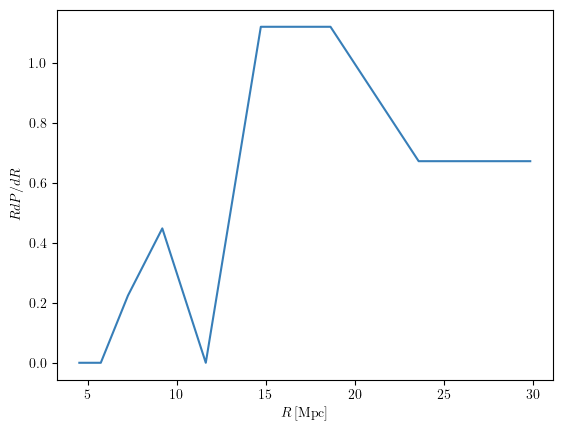

In [27]:
plt.plot(rbins, dP_dR * rbins )
plt.xlabel(r'$R\,[\rm Mpc]$')
plt.ylabel(r'$R dP/dR$')
